In [83]:
import time
import numpy as np
from IPython.display import clear_output

from numpy.polynomial.legendre import leggauss

from scipy.linalg import inv, solve, eigh, pinv
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import LinearOperator, cg

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update(
    {
        "font.size": 24,
        "axes.labelsize": 24,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
        "lines.linewidth": 3,
    }
)

In [84]:
def leggauss_diff(x):
    x = np.asarray(x, dtype=float)
    n = x.size

    X = x[:, None]
    dX = X - X.T

    # barycentric weights
    w = 1.0 / np.prod(dX + np.eye(n), axis=1)

    # differentiation matrix
    D = (w[None, :] / w[:, None]) / (dX + np.eye(n))
    np.fill_diagonal(D, 0.0)
    np.fill_diagonal(D, -D.sum(axis=1))

    return D

In [85]:
# --- Parameters ---
nx, ny = 35, 35
n = (nx + 1) * (ny + 1)

In [86]:
# --- 1D setup ---
x_grid, wx = leggauss(nx+1)
y_grid, wy = leggauss(ny+1)

dx = leggauss_diff(x_grid)
dy = leggauss_diff(y_grid)

dx_s = (1 / wx).reshape(-1, 1) * (dx.T) * wx
dy_s = (1 / wy).reshape(-1, 1) * dy.T * wy

In [ ]:
# --- 2D tensor-product operators ---
Wxy = np.diag(np.kron(wy, wx))
Wxy_inv = inv(Wxy)

Ix = np.eye(nx + 1)
Iy = np.eye(ny + 1)

Dx = np.kron(Iy, dx)
Dy = np.kron(dy, Ix)
Dxx = Dx @ Dx
Dxy = Dx @ Dy
Dyy = Dy @ Dy
Lap = Dxx + Dyy

X, Y = np.meshgrid(x_grid, y_grid, indexing="ij")

B_H1 = Wxy + Dx.T @ Wxy @ Dx + Dy.T @ Wxy @ Dy
B_H2 = B_H1 + Dxx.T @ Wxy @ Dxx + Dxy.T @ Wxy @ Dxy + Dyy.T @ Wxy @ Dyy

B_H1 = 0.5 * (B_H1 + B_H1.T)
B_H2 = 0.5 * (B_H2 + B_H2.T)

In [88]:
# --- Hmats ---
Ixy = np.kron(Iy, Ix)
Dx_s = np.kron(Iy, dx_s)
Dy_s = np.kron(dy_s, Ix)

Hmat = Ixy + Dx_s @ Dx + Dy_s @ Dy
Hmat_s = Ixy + Dx @ Dx_s + Dy @ Dy_s
Hmat = 0.5 * (Hmat + Wxy_inv @ Hmat.T @ Wxy)
Hmat_s = 0.5 * (Hmat_s + Wxy_inv @ Hmat_s.T @ Wxy)

In [89]:
# --- Pseudoinverses ---
Hmat_pinv = pinv(Hmat)
Hmat_s_pinv = pinv(Hmat_s)

In [90]:
# --- CG Hmats ---
Ixy_sp = csr_matrix(Ixy)
Wxy_sp = csr_matrix(Wxy)
Dx_sp, Dy_sp = csr_matrix(Dx), csr_matrix(Dy)
Dx_s_sp, Dy_s_sp = csr_matrix(Dx_s), csr_matrix(Dy_s)

Hmat_sp = Ixy_sp + Dx_s_sp @ Dx_sp + Dy_s_sp @ Dy_sp
Hmat_sp_s = Ixy_sp + Dx_sp @ Dx_s_sp + Dy_sp @ Dy_s_sp

Hmat_sp_diag = Hmat_sp.diagonal()
Hmat_sp_s_diag = Hmat_sp_s.diagonal()

M_sp = LinearOperator((n, n), matvec=lambda v: v / Hmat_sp_diag, dtype=np.float64)
M_sp_s = LinearOperator((n, n), matvec=lambda v: v / Hmat_sp_s_diag, dtype=np.float64)

In [91]:
# --- SINOS worst case---
A = Lap.T @ Wxy @ solve(Hmat, Lap)
A = 0.5 * (A + A.T)

eigvals, eigvecs = eigh(A, B_H2)
x_bad = eigvecs[:, -1].real
x_bad /= np.sqrt(x_bad @ (B_H2 @ x_bad))

lap_x_bad = Lap @ x_bad
x_bad_neg_norm = np.sqrt(lap_x_bad @ Wxy @ solve(Hmat, lap_x_bad))

x_bad_H1_norm = np.sqrt(x_bad @ (B_H1 @ x_bad))
x_bad_H2_norm = np.sqrt(x_bad @ (B_H2 @ x_bad))

max_ratio_H1 = x_bad_neg_norm / x_bad_H1_norm
max_ratio_H2 = x_bad_neg_norm / x_bad_H2_norm

print(f"SINOS worst case:")
print(f"  Relative to H1 norm: {max_ratio_H1:.2f}")
print(f"  Relative to H2 norm: {max_ratio_H2:.2f}")

SINOS worst case:
  Relative to H1 norm: 2.55
  Relative to H2 norm: 1.23


In [92]:
# --- D-SINOS worst case ---
A_s = Lap.T @ Wxy @ solve(Hmat_s, Lap)
A_s = 0.5 * (A_s + A_s.T)

eigvals_s, eigvecs_s = eigh(A_s, B_H2)
x_bad_s = eigvecs_s[:, -1].real
x_bad_s /= np.sqrt(x_bad_s @ (B_H2 @ x_bad_s))

lap_x_bad_s = Lap @ x_bad_s
x_bad_s_neg_norm = np.sqrt(lap_x_bad_s @ Wxy @ solve(Hmat_s, lap_x_bad_s))

x_bad_s_H1_norm = np.sqrt(x_bad_s @ (B_H1 @ x_bad_s))
x_bad_s_H2_norm = np.sqrt(x_bad_s @ (B_H2 @ x_bad_s))
max_ratio_s_H1 = x_bad_s_neg_norm / x_bad_s_H1_norm
max_ratio_s_H2 = x_bad_s_neg_norm / x_bad_s_H2_norm

print(f"D-SINOS worst case:")
print(f"  Relative to H1 norm: {max_ratio_s_H1:.2f}")
print(f"  Relative to H2 norm: {max_ratio_s_H2:.2f}")

D-SINOS worst case:
  Relative to H1 norm: 0.85
  Relative to H2 norm: 0.46


In [93]:
times = []
results = []
for k in range(10_000):
    # Print progress
    clear_output(wait=True)
    print(k)

    # Generate a random vector with random sparsity level p
    p = np.random.rand(1)
    mask = np.random.rand(n) < p
    if not np.any(mask):
        mask[np.random.randint(n)] = True
    x = np.zeros(n)
    x[mask] = np.random.rand(np.sum(mask))
    x /= np.sqrt(x @ (B_H2 @ x))

    lap_x = Lap @ x

    x_H1_norm = np.sqrt(x @ (B_H1 @ x))
    x_H2_norm = 1.0

    # Direct
    t0_neg_norm = time.perf_counter()
    x_neg_norm = np.sqrt((lap_x @ Wxy @ solve(Hmat, lap_x)))
    t1_neg_norm = time.perf_counter() - t0_neg_norm

    t0_dual_neg_norm = time.perf_counter()
    x_dual_neg_norm = np.sqrt((lap_x @ Wxy @ solve(Hmat_s, lap_x)))
    t1_dual_neg_norm = time.perf_counter() - t0_dual_neg_norm

    # Pseudoinverse
    t0_neg_norm_pinv = time.perf_counter()
    x_neg_norm_pinv = np.sqrt((lap_x @ Wxy @ (Hmat_pinv @ lap_x)))
    t1_neg_norm_pinv = time.perf_counter() - t0_neg_norm_pinv

    t0_dual_neg_norm_pinv = time.perf_counter()
    x_dual_neg_norm_pinv = np.sqrt((lap_x @ Wxy @ (Hmat_s_pinv @ lap_x)))
    t1_dual_neg_norm_pinv = time.perf_counter() - t0_dual_neg_norm_pinv

    # CG
    t0_neg_norm_cg = time.perf_counter()
    u, _ = cg(Hmat_sp, lap_x, M=M_sp, rtol=1e-12, atol=0.0, maxiter=5)
    x_neg_norm_cg = np.sqrt(lap_x @ (Wxy @ u))
    t1_neg_norm_cg = time.perf_counter() - t0_neg_norm_cg

    t0_dual_neg_norm_cg = time.perf_counter()
    u_s, _ = cg(Hmat_sp_s, lap_x, M=M_sp_s, rtol=1e-12, atol=0.0, maxiter=5)
    x_dual_neg_norm_cg = np.sqrt(lap_x @ (Wxy @ u_s))
    t1_dual_neg_norm_cg = time.perf_counter() - t0_dual_neg_norm_cg

    # ---- Store ----
    results.append(
        [
            x_H1_norm,
            x_H2_norm,
            x_neg_norm,
            x_dual_neg_norm,
            x_neg_norm_pinv,
            x_dual_neg_norm_pinv,
            x_neg_norm_cg,
            x_dual_neg_norm_cg,
        ]
    )
    times.append(
        [
            t1_neg_norm,
            t1_dual_neg_norm,
            t1_neg_norm_pinv,
            t1_dual_neg_norm_pinv,
            t1_neg_norm_cg,
            t1_dual_neg_norm_cg,
        ]
    )
results = np.copy(results)
times = np.copy(times) * 1000

9999


In [114]:
mpl.rcParams.update(
    {
        "font.size": 22,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 18,
        "lines.linewidth": 3,
    }
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


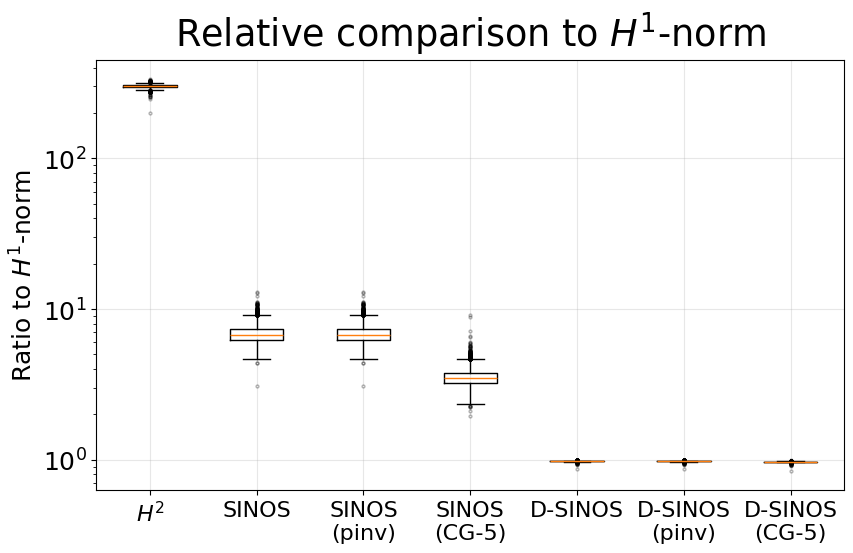

In [ ]:
# We have to exclude NaN values of SINOS CG
mask = ~np.isnan(results[:, 6])
results_clean = np.copy(results[mask])

# Compute ratios relative to H1
ratios = results_clean[:, 1:] / results_clean[:, [0]]  # shape: (N, 5)

# Re-ordering
perm = [0, 1, 3, 5, 2, 4, 6]
ratios = ratios[:, perm]

plt.figure(figsize=(9, 6))

plt.boxplot(
    ratios,
    whis=1.5,
    tick_labels=[
        "$H^2$",
        "SINOS",
        "SINOS\n(pinv)",
        "SINOS\n(CG-5)",
        "D-SINOS",
        "D-SINOS\n(pinv)",
        "D-SINOS\n(CG-5)",
    ],
    flierprops=dict(markersize=2, alpha=0.3),
)

plt.yscale("log")
plt.ylabel("Ratio to $H^1$-norm")
plt.title("Relative comparison to $H^1$-norm", pad=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("media/relative_comparsion_to_H1_norm.eps", format="eps")
plt.savefig("media/relative_comparsion_to_H1_norm.png", dpi=600)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


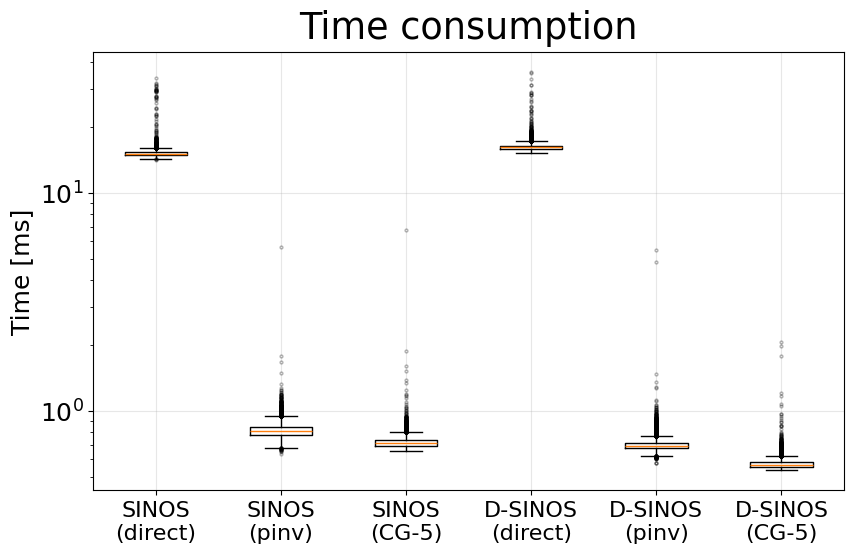

In [118]:
import matplotlib.pyplot as plt

# Re-ordering
perm = [0, 2, 4, 1, 3, 5]
times_perm = np.copy(times[:, perm])

plt.figure(figsize=(9, 6))

plt.boxplot(
    times_perm,
    whis=1.5,
    tick_labels=[
        "SINOS\n(direct)",
        "SINOS\n(pinv)",
        "SINOS\n(CG-5)",
        "D-SINOS\n(direct)",
        "D-SINOS\n(pinv)",
        "D-SINOS\n(CG-5)",
    ],
    flierprops=dict(markersize=2, alpha=0.3),
)
plt.yscale("log")
plt.ylabel("Time [ms]")
plt.title("Time consumption", pad=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("media/time_consumption.eps", format="eps")
plt.savefig("media/time_consumption.png", dpi=600)
plt.show()